In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
park_agg = pd.read_csv("../data/clean/park_agg.csv")
park_agg["Crowding Levels"] = pd.qcut(park_agg['Recreation Visits'], q=3, labels=['Low', 'Medium', 'High'])
print(park_agg['Crowding Levels'].value_counts())

Crowding Levels
Low       20
High      20
Medium    19
Name: count, dtype: int64


In [8]:
dt_feats = ["Non Recreation Visits","Non Recreation Hours","Concessioner Lodging","Concessioner Camping","Tent Campers","RV Campers",
"Backcountry","Miscellaneous Overnight Stays","Number of Activities","Entrance Fees"]
x = park_agg[dt_feats].copy()
y = park_agg["Crowding Levels"].copy()

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)
print("\nTraining class counts:")
print(y_train.value_counts())
print("\nTesting class counts:")
print(y_test.value_counts())

Training set shape: (47, 10)
Testing set shape: (12, 10)

Training class counts:
Crowding Levels
Low       16
High      16
Medium    15
Name: count, dtype: int64

Testing class counts:
Crowding Levels
Low       4
Medium    4
High      4
Name: count, dtype: int64


In [ ]:
model_normal = DecisionTreeClassifier(criterion='entropy', random_state=12)
model_gini = DecisionTreeClassifier(criterion='gini', random_state=12)
model_custom = DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=0.06, random_state=12) #Setting a higher threshold stops the tree from creating weak rules
model_normal.fit(x_train, y_train)
model_gini.fit(x_train, y_train)
model_custom.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",12
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [67]:
model_normal.fit(x_train, y_train)
model_gini.fit(x_train, y_train)
model_custom.fit(x_train, y_train)
preds_normal = model_normal.predict(x_test)
preds_gini = model_gini.predict(x_test)
preds_custom = model_custom.predict(x_test)
print("Entropy Tree Test Accuracy:", round(accuracy_score(y_test, preds_normal), 3))
print("Gini Tree Test Accuracy:", round(accuracy_score(y_test, preds_gini), 3))
print("Custom Entropy Test Accuracy:", round(accuracy_score(y_test, preds_custom), 3))

Entropy Tree Test Accuracy: 0.417
Gini Tree Test Accuracy: 0.333
Custom Entropy Test Accuracy: 0.5


Text(0.5, 1.0, 'Entropy Decision Tree')

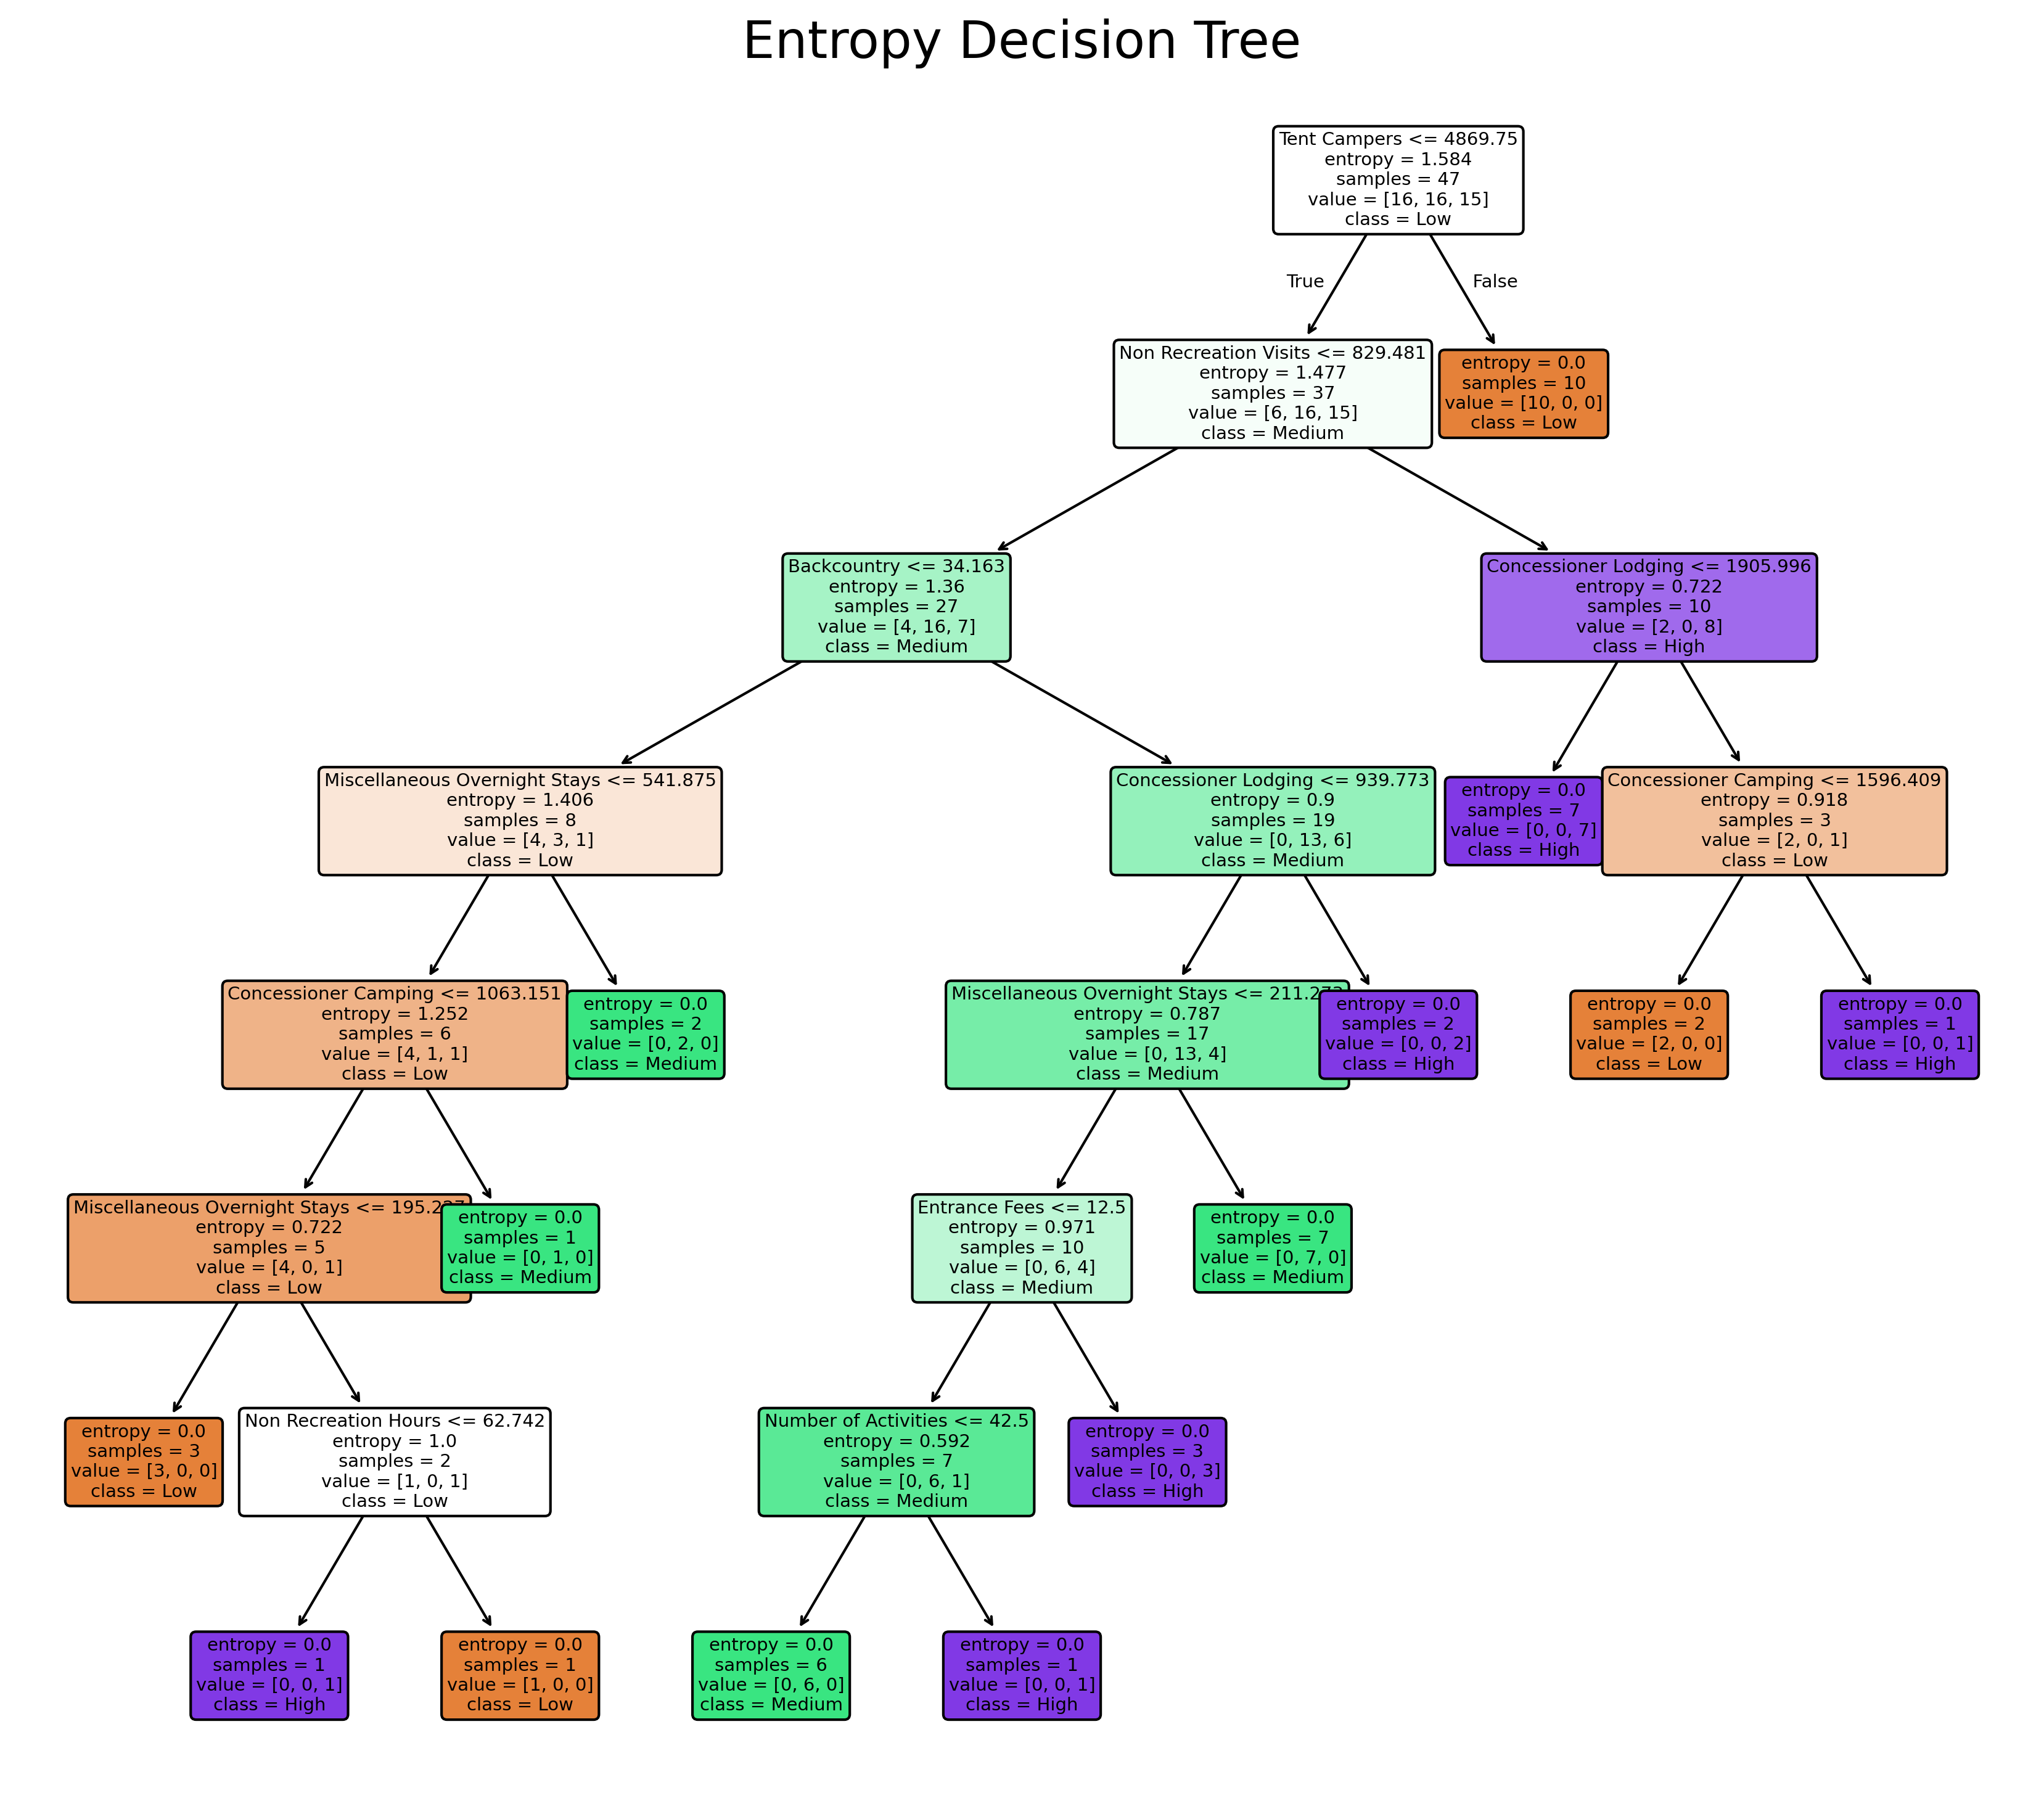

In [65]:
plt.figure(figsize=(14, 12), dpi=300)
plot_tree(model_normal, feature_names=dt_feats, class_names=['Low', 'Medium', 'High'], filled=True, rounded=True, fontsize=7)
plt.title("Entropy Decision Tree", fontsize=20)

Text(0.5, 1.0, 'Gini Decision Tree')

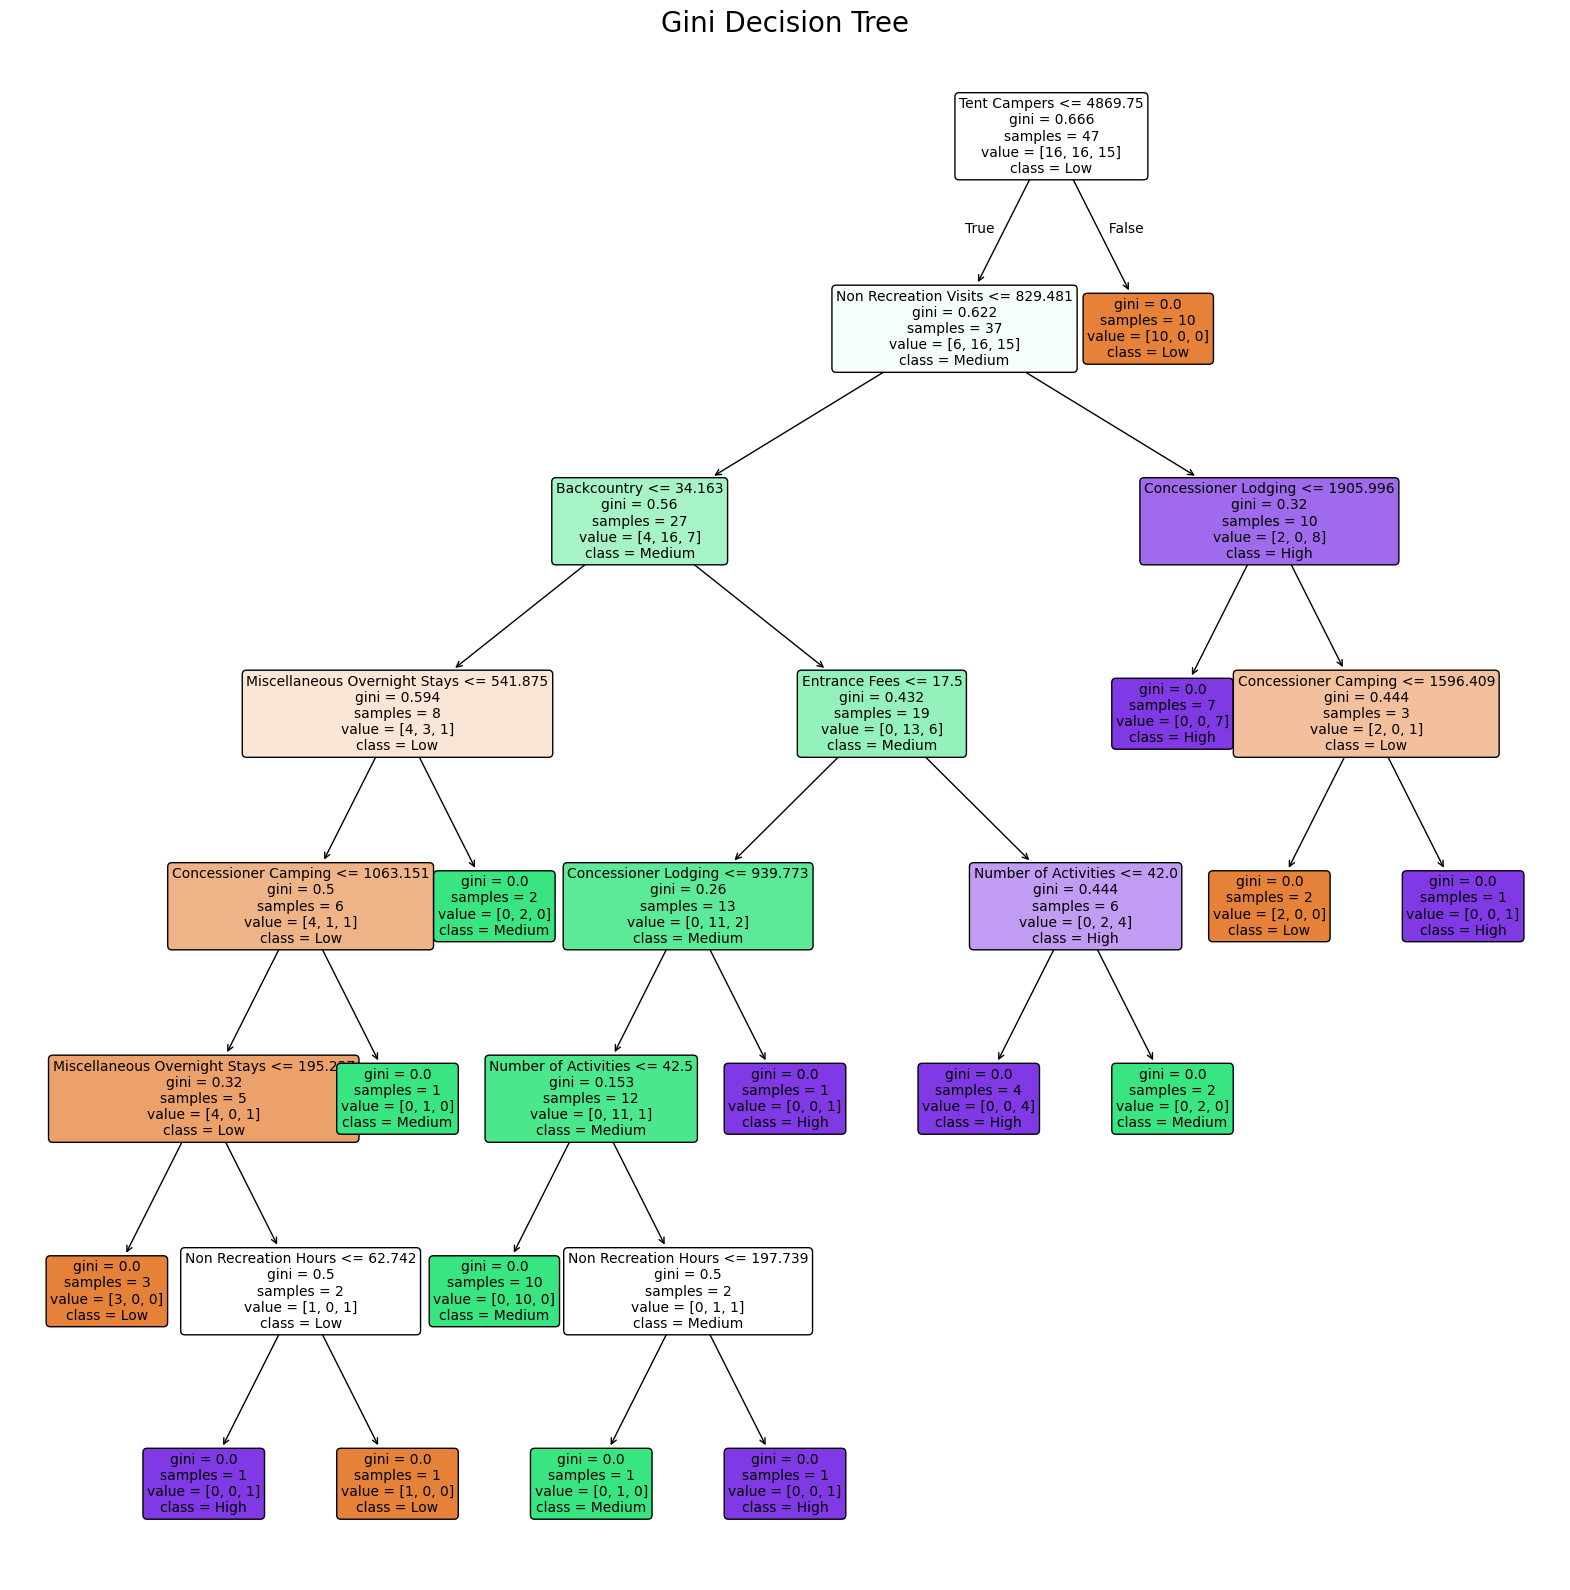

In [58]:
plt.figure(figsize=(20,20))
plot_tree(model_gini,feature_names=dt_feats, class_names=['Low', 'Medium', 'High'], filled=True, rounded=True,fontsize=10)
plt.title("Gini Decision Tree", fontsize=20)


Text(0.5, 1.0, 'Custom Entropy Decision Tree')

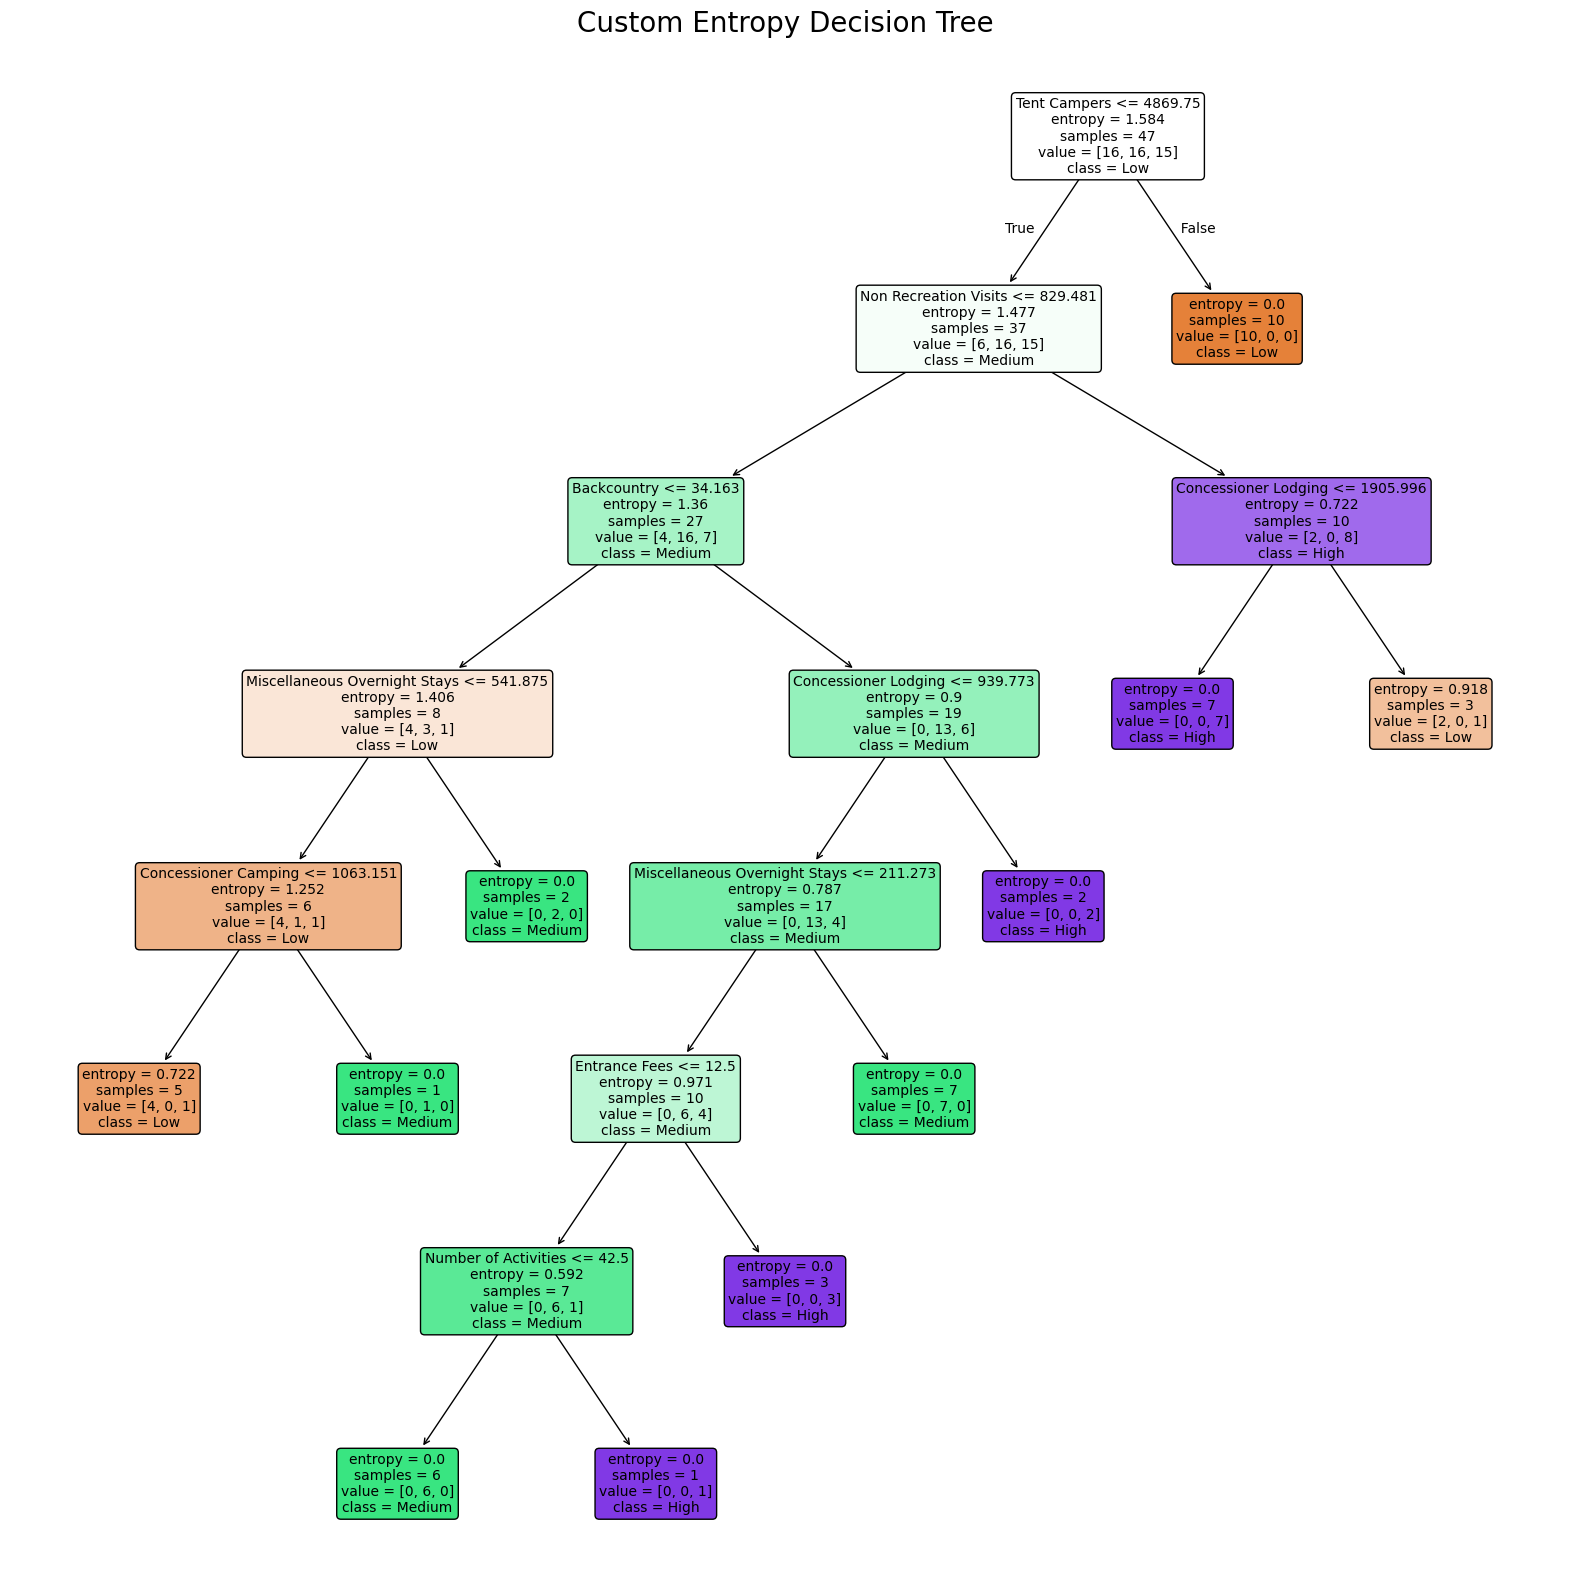

In [ ]:
plt.figure(figsize=(20,20))
plot_tree(model_custom,feature_names=dt_feats, class_names=['Low', 'Medium', 'High'], filled=True, rounded=True,fontsize=10)
plt.title("Custom Entropy Decision Tree", fontsize=20)

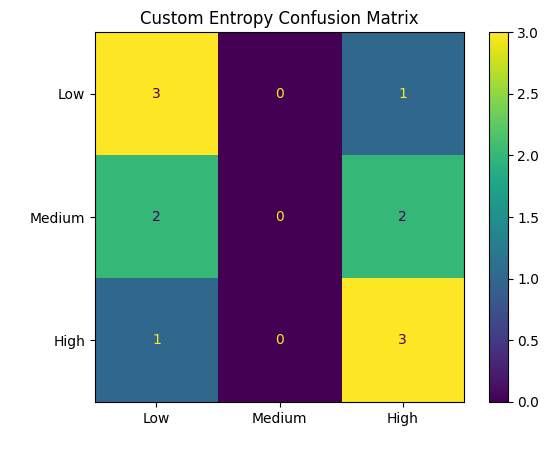

In [71]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_custom, display_labels=['Low', 'Medium', 'High'])
plt.title('Custom Entropy Confusion Matrix')
plt.ylabel(' ')
plt.xlabel(' ')
plt.show()